In [20]:
import sys
import subprocess

try:
    from easypip import easyimport
except ModuleNotFoundError:
    subprocess.run([sys.executable, "-m", "pip", "install", "easypip"], check=True)
    from easypip import easyimport

easyimport("swig")
easyimport("bbrl_utils").setup(maze_mdp=True)


import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from omegaconf import OmegaConf
import bbrl_gymnasium


In [21]:
def make_mdp_env(width, height, ratio, render_mode="rgb_array"):
    return gym.make(
        "MazeMDP-v0",
        render_mode=render_mode,
        kwargs={"width": width, "height": height, "ratio": ratio},
    )

In [22]:
PARAMS = {
    "width": 5,
    "height": 5,
    "ratio": 0.2,
    "nb_episodes": 200,
    "alpha": 0.1,
    "gamma": 0.99,
    "epsilon": 0.3,
    "epsilon_decay": 0.99,
    "nb_repeats": 5,
}

In [23]:
env = make_mdp_env(PARAMS["width"], PARAMS["height"], PARAMS["ratio"])
nb_states = env.observation_space.n
nb_actions = env.action_space.n

In [24]:
def choose_action(q_values, epsilon, state):
    if np.random.random() < epsilon:
        return np.random.randint(nb_actions)
    return np.argmax(q_values[state])

In [25]:
def sarsa_update(q_values, state, action, reward, next_state, next_action, alpha, gamma, terminated):
    current_q = q_values[state, action]
    next_q = 0 if terminated else q_values[next_state, next_action]
    td_error = reward + gamma * next_q - current_q
    q_values[state, action] = current_q + alpha * td_error
    return td_error


def q_learning_max_update(q_values, state, action, reward, next_state, alpha, gamma, terminated):
    current_max = q_values[state].max()
    next_max = 0 if terminated else q_values[next_state].max()
    td_error = reward + gamma * next_max - current_max
    q_values[state, action] += alpha * td_error
    return td_error


def mean_sarsa_update(q_values, state, action, reward, next_state, policy, alpha, gamma, terminated):
    baseline = (policy[state] * q_values[state]).sum()
    next_max = 0 if terminated else q_values[next_state].max()
    td_error = reward + gamma * next_max - baseline
    q_values[state, action] += alpha * td_error
    return td_error


def standard_q_learning_update(q_values, state, action, reward, next_state, alpha, gamma, terminated):
    current_q = q_values[state, action]
    next_max = 0 if terminated else q_values[next_state].max()
    td_error = reward + gamma * next_max - current_q
    q_values[state, action] = current_q + alpha * td_error
    return td_error


def update_policy(policy, q_values, state, td_error):
    if td_error > 0:
        best = np.argmax(q_values[state])
        policy[state] = np.eye(nb_actions)[best]
    return policy

In [26]:
def run_episode(env, q_values, policy, alpha, gamma, epsilon, update_type):
    state, _ = env.reset()
    done = False
    steps = 0
    total_reward = 0
    while not done and steps < 500:
        action = choose_action(q_values, epsilon, state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        reward = reward - 0.01
        next_action = choose_action(q_values, epsilon, next_state)
        if update_type == 1:
            td = sarsa_update(q_values, state, action, reward, next_state, next_action, alpha, gamma, terminated)
        elif update_type == 2:
            td = q_learning_max_update(q_values, state, action, reward, next_state, alpha, gamma, terminated)
        elif update_type == 3:
            td = mean_sarsa_update(q_values, state, action, reward, next_state, policy, alpha, gamma, terminated)
        else:
            td = standard_q_learning_update(q_values, state, action, reward, next_state, alpha, gamma, terminated)
        policy = update_policy(policy, q_values, state, td)
        state = next_state
        total_reward += reward
        steps += 1
        done = terminated or truncated
    return steps, total_reward

In [27]:
def run_actor_critic(env, update_type, nb_episodes, alpha, gamma, epsilon_init, epsilon_decay, nb_repeats):
    all_steps, all_rewards = [], []
    for _ in range(nb_repeats):
        q_values = np.zeros((nb_states, nb_actions))
        policy = np.ones((nb_states, nb_actions)) / nb_actions
        eps = epsilon_init
        steps_hist, reward_hist = [], []
        for _ in range(nb_episodes):
            s, r = run_episode(env, q_values, policy, alpha, gamma, eps, update_type)
            steps_hist.append(s)
            reward_hist.append(r)
            eps *= epsilon_decay
        all_steps.append(steps_hist)
        all_rewards.append(reward_hist)
    return np.array(all_steps), np.array(all_rewards)

In [28]:
def plot_metric(all_data, title, ylabel, smoothing=5):
    mean = all_data.mean(axis=0)
    std = all_data.std(axis=0)
    if smoothing > 1:
        kern = np.ones(smoothing) / smoothing
        mean = np.convolve(mean, kern, mode='valid')
        std = np.convolve(std, kern, mode='valid')
        x = np.arange(smoothing-1, len(mean)+smoothing-1)
    else:
        x = np.arange(len(mean))
    plt.figure(figsize=(8,5))
    plt.plot(x, mean, label='Mean')
    plt.fill_between(x, mean-std, mean+std, alpha=0.3)
    plt.title(f"{ylabel} par épisode - {title}")
    plt.xlabel('Épisode')
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.show()


Running Actor-Critic...

Algorithm: SARSA


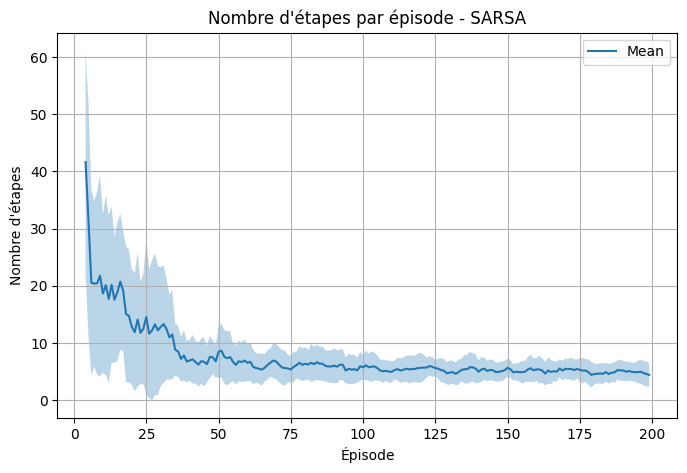

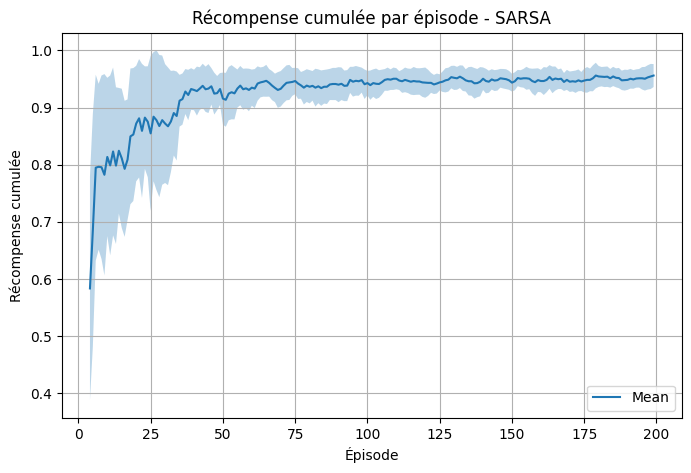

Algorithm: Q-learning (max)


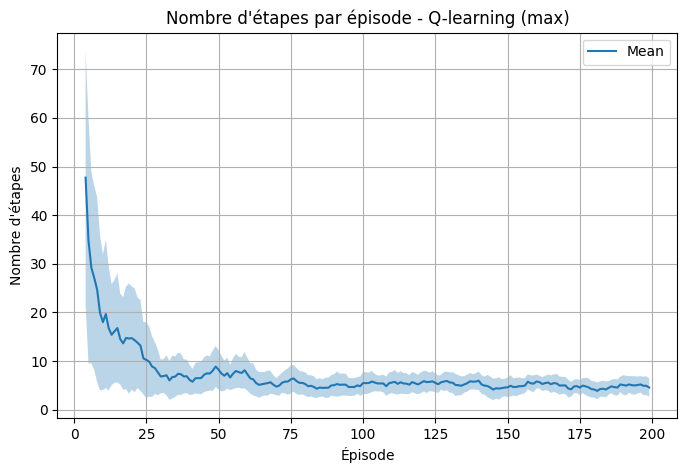

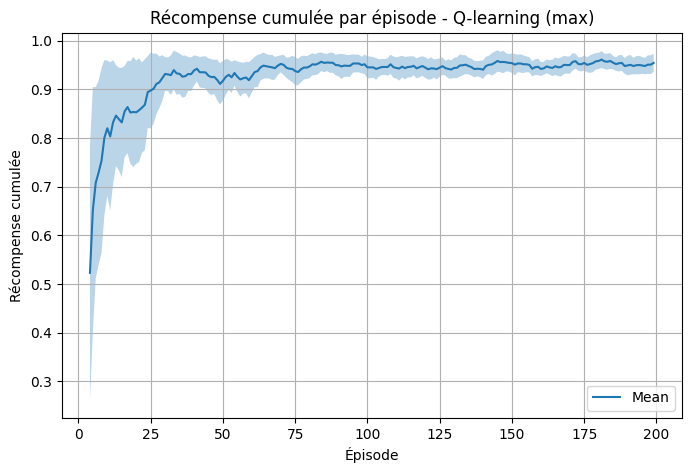

Algorithm: Mean SARSA


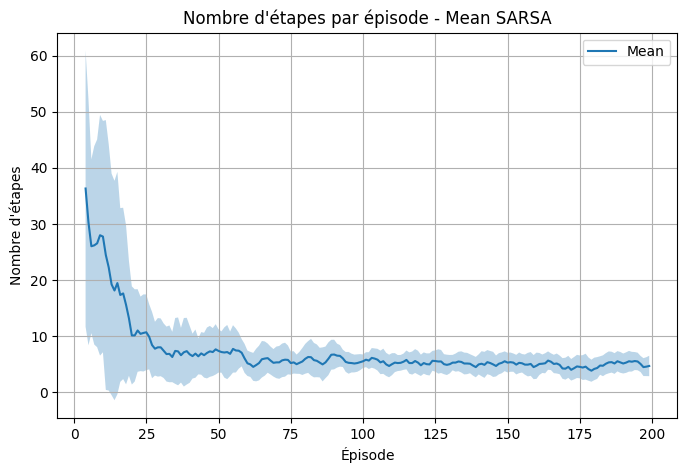

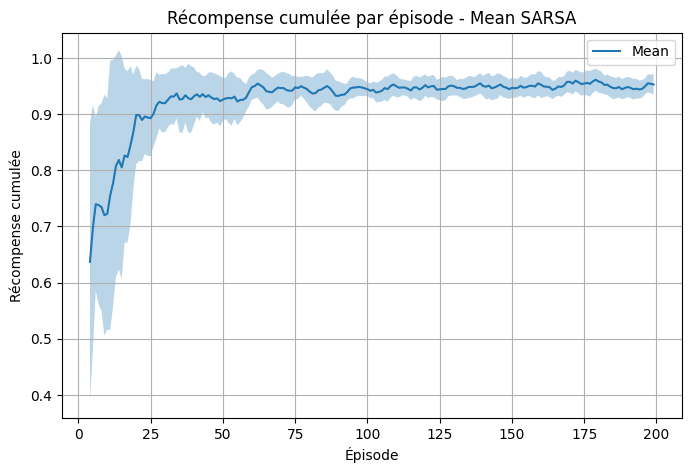

Algorithm: Standard Q-learning


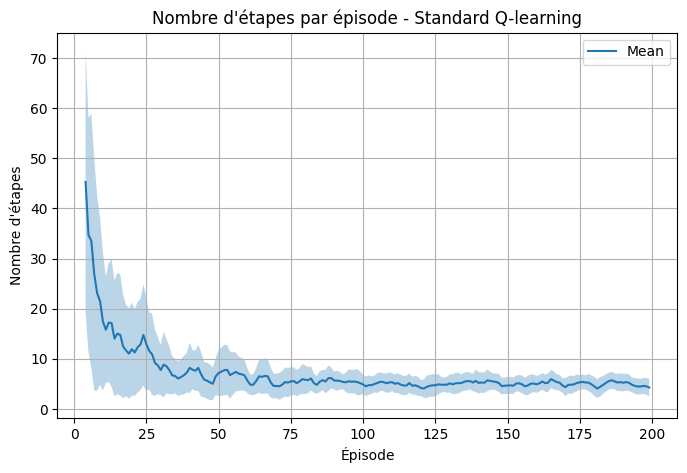

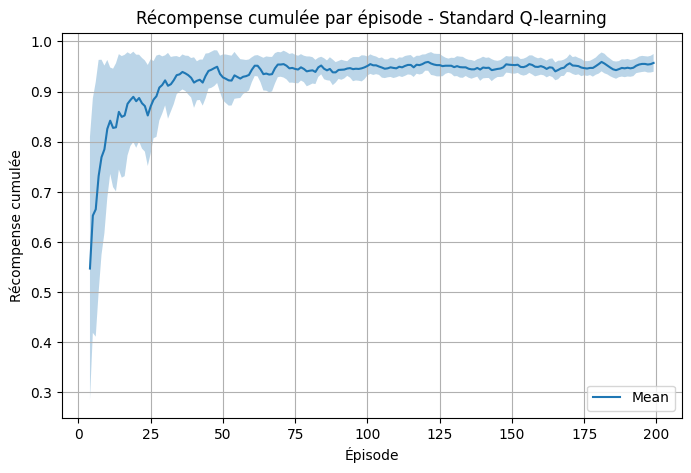

In [29]:
print("Running Actor-Critic...\n")
update_names = ["SARSA", "Q-learning (max)", "Mean SARSA", "Standard Q-learning"]
results = []
for u, name in enumerate(update_names, start=1):
    print(f"Algorithm: {name}")
    steps, rewards = run_actor_critic(
        env, u, PARAMS['nb_episodes'], PARAMS['alpha'], PARAMS['gamma'],
        PARAMS['epsilon'], PARAMS['epsilon_decay'], PARAMS['nb_repeats']
    )
    plot_metric(steps, name, 'Nombre d\'étapes')
    plot_metric(rewards, name, 'Récompense cumulée')
    results.append((steps, rewards))

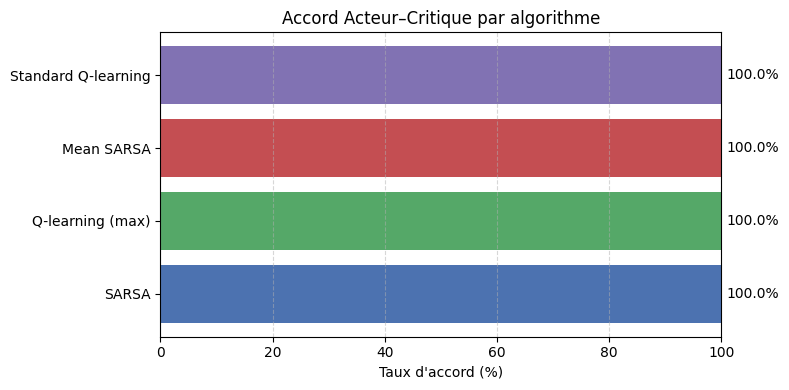

In [35]:
import numpy as np
import matplotlib.pyplot as plt

update_names = ["SARSA", "Q-learning (max)", "Mean SARSA", "Standard Q-learning"]

agreement_percents = []
for u, name in enumerate(update_names, start=1):
    q_values = np.zeros((nb_states, nb_actions))
    policy   = np.ones((nb_states, nb_actions)) / nb_actions
    eps      = PARAMS['epsilon']
    for _ in range(PARAMS['nb_episodes']):
        _, _ = run_episode(env, q_values, policy,
                           PARAMS['alpha'], PARAMS['gamma'],
                           eps, u)
        eps *= PARAMS['epsilon_decay']
    actor_actions  = np.argmax(policy,   axis=1)
    critic_actions = np.argmax(q_values, axis=1)
    agreement_percents.append((actor_actions == critic_actions).mean() * 100)

plt.figure(figsize=(8, 4))
bars = plt.barh(update_names, agreement_percents, color=['#4C72B0','#55A868','#C44E52','#8172B3'])
plt.xlim(0, 100)
plt.xlabel("Taux d'accord (%)")
plt.title("Accord Acteur–Critique par algorithme")
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar, pct in zip(bars, agreement_percents):
    plt.text(pct + 1, bar.get_y() + bar.get_height()/2,
             f"{pct:.1f}%", va='center', fontsize=10)

plt.tight_layout()
plt.show()

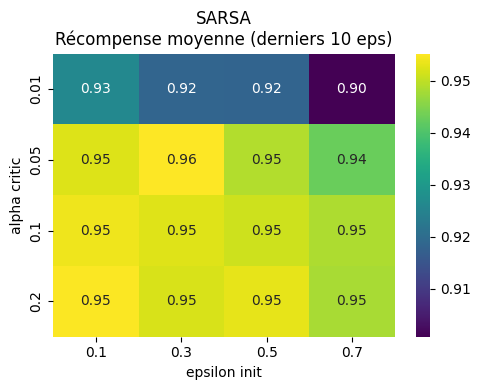

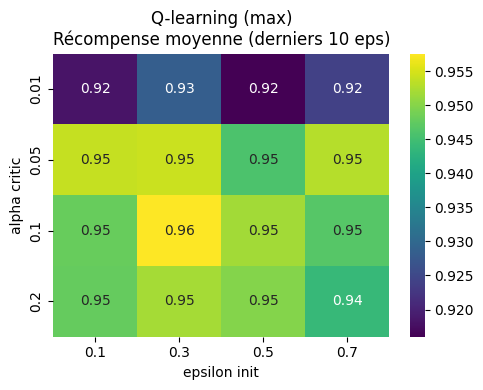

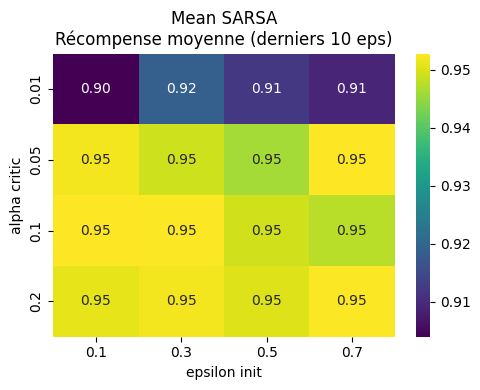

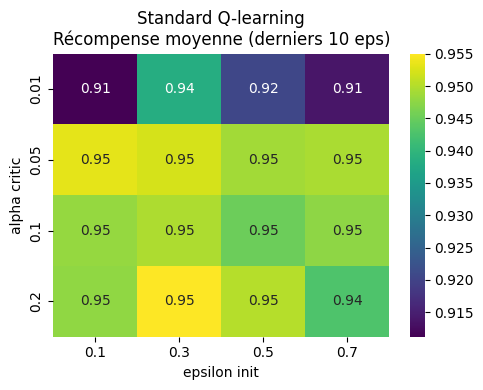

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

update_types = [1, 2, 3, 4]
update_names = ["SARSA", "Q-learning (max)", "Mean SARSA", "Standard Q-learning"]

alphas   = [0.01, 0.05, 0.1, 0.2]
epsilons = [0.1, 0.3, 0.5, 0.7]
gamma    = PARAMS['gamma']
decay    = PARAMS['epsilon_decay']
nb_eps   = PARAMS['nb_episodes']
nb_rep   = PARAMS['nb_repeats']

for u, name in zip(update_types, update_names):
    heatmap = np.zeros((len(alphas), len(epsilons)))
    for i, alpha in enumerate(alphas):
        for j, eps0 in enumerate(epsilons):
            _, rewards = run_actor_critic(
                env, u,
                nb_episodes=nb_eps,
                alpha=alpha,
                gamma=gamma,
                epsilon_init=eps0,
                epsilon_decay=decay,
                nb_repeats=nb_rep
            )
            heatmap[i, j] = rewards[:, -10:].mean()
    plt.figure(figsize=(5,4))
    sns.heatmap(
        heatmap,
        xticklabels=epsilons,
        yticklabels=alphas,
        annot=True,
        fmt=".2f",
        cmap="viridis"
    )
    plt.xlabel("epsilon init")
    plt.ylabel("alpha critic")
    plt.title(f"{name}\nRécompense moyenne (derniers 10 eps)")
    plt.tight_layout()
    plt.show()

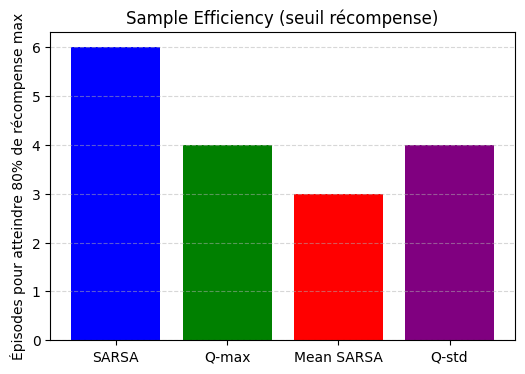

In [51]:
import numpy as np
import matplotlib.pyplot as plt

methods = {1:"SARSA",2:"Q-max",3:"Mean SARSA",4:"Q-std"}
threshold = 0.8
efficiencies = []

for u,name in methods.items():
    _, rewards = run_actor_critic(
        env, u,
        nb_episodes=PARAMS['nb_episodes'],
        alpha=PARAMS['alpha'],
        gamma=PARAMS['gamma'],
        epsilon_init=PARAMS['epsilon'],
        epsilon_decay=PARAMS['epsilon_decay'],
        nb_repeats=PARAMS['nb_repeats']
    )
    mean_rew = rewards.mean(axis=0)
    T = next((i for i in range(len(mean_rew)-9)
              if mean_rew[i:i+10].mean() >= threshold),
             PARAMS['nb_episodes'])
    efficiencies.append(T)

plt.figure(figsize=(6,4))
plt.bar(list(methods.values()), efficiencies, color=['blue','green','red','purple'])
plt.ylabel("Épisodes pour atteindre 80% de récompense max")
plt.title("Sample Efficiency (seuil récompense)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

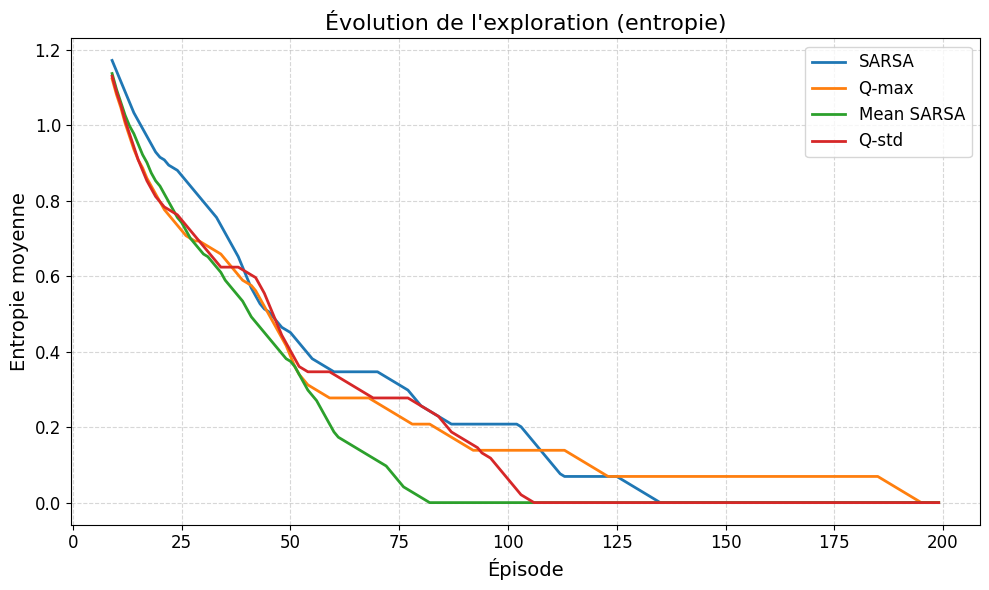

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

entropies = {u: [] for u in methods}
for u in methods:
    q = np.zeros((nb_states, nb_actions))
    π = np.ones((nb_states, nb_actions)) / nb_actions
    eps = PARAMS['epsilon']
    for _ in range(PARAMS['nb_episodes']):
        _, _ = run_episode(env, q, π,
                           PARAMS['alpha'], PARAMS['gamma'],
                           eps, u)
        eps *= PARAMS['epsilon_decay']
        entropies[u].append(
            np.mean([st.entropy(π[s]) for s in range(nb_states)])
        )

window = 10
plt.figure(figsize=(10, 6))
for u, name in methods.items():
    vals = np.array(entropies[u])
    kern = np.ones(window) / window
    smooth = np.convolve(vals, kern, mode='valid')
    x = np.arange(window - 1, PARAMS['nb_episodes'])
    plt.plot(x, smooth, label=name, linewidth=2)

plt.xlabel("Épisode", fontsize=14)
plt.ylabel("Entropie moyenne", fontsize=14)
plt.title("Évolution de l'exploration (entropie)", fontsize=16)  # titre sans mention du lissage
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()
